In [1]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import accuracy_score

In [2]:
#load data
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

In [3]:
#mark Labels
labels = np.copy(y)
rng = np.random.RandomState(42)
mask = rng.rand(len(y)) < 0.1
labels[~mask] = -1
print(f"Labeled: {np.sum(mask)}, Unlabeled: {np.sum(~mask)}")

Labeled: 18, Unlabeled: 132


In [4]:
#train
model = LabelPropagation()
model.fit(X, labels)

LabelPropagation()

In [5]:
#transducion and evaluation
y_pred = model.transduction_
acc_labeled = accuracy_score(y[mask], y_pred[mask])
acc_overall = accuracy_score(y, y_pred)
print(f"Acc (on original labeled subset): {acc_labeled:.3f}")
print(f"Acc (overall after propagation): {acc_overall:.3f}")

Acc (on original labeled subset): 1.000
Acc (overall after propagation): 0.707


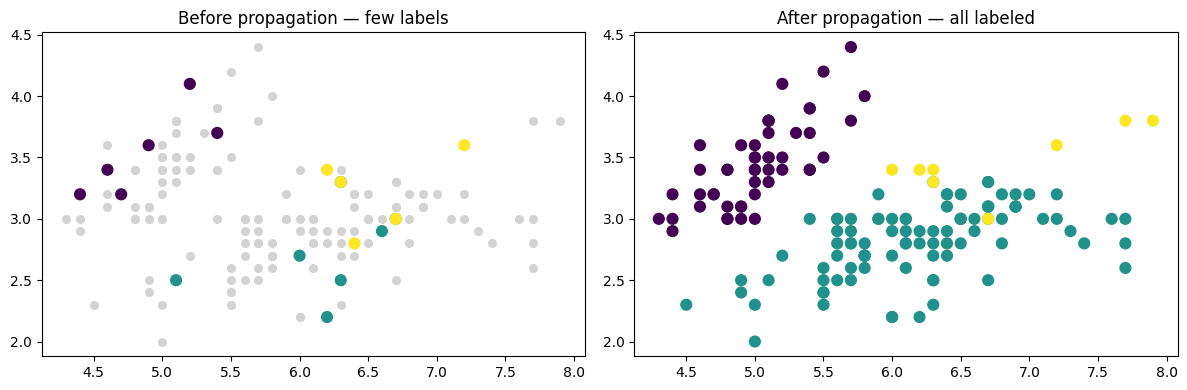

In [6]:
#visualize results
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(X[:, 0], X[:, 1], c='lightgray', s=30)
ax[0].scatter(X[mask, 0], X[mask, 1], c=y[mask], cmap='viridis', s=60)
ax[0].set_title("Before propagation — few labels")

ax[1].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=60)
ax[1].set_title("After propagation — all labeled")

plt.tight_layout()
plt.show()